# 05 — Cleveland: considering the predictors together

**Phase 3, Step 3.** Notebooks 03 and 04 looked at one predictor at a time.
But the predictors overlap: exercise angina, ST depression, ST slope and max
heart rate all come from the same exercise test. If they partly measure the
same thing, their one-at-a-time effects can't be added up.

A **logistic regression** estimates each predictor's association with disease
*while holding the others constant*. Its question is: among patients who are
alike on every other predictor in the model, does this one still make a
difference?

**What a logistic regression gives you: odds ratios.** The *odds* of disease
are p / (1 − p): a 50% chance is odds of 1, a 75% chance is odds of 3. An
**odds ratio (OR)** compares the odds between two patients who differ in one
predictor:
- OR = 1: no difference.
- OR = 2: the odds of disease are twice as high.
- OR = 0.5: the odds are half as high.

**Still an association, not a cause.** "Holding the others constant" only
covers the predictors in the model. And every patient was referred for
angiography, so results describe referred patients.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from clean_data import load_clean  # noqa: E402

df = load_clean()
cle = df[df["site"] == "cleveland"].dropna(subset=["major_vessels", "thallium_result"]).copy()
print(f"Complete cases: {len(cle)} patients, {int(cle['disease'].sum())} with disease "
      f"(6 patients dropped for a missing vessel count or thallium result)")

Complete cases: 297 patients, 137 with disease (6 patients dropped for a missing vessel count or thallium result)


## 1. Preparing the predictors

Three modelling decisions, each made *before* looking at the results:

1. **Units for numeric predictors.** An odds ratio "per 1 mg/dl of
   cholesterol" would be a tiny, unreadable number. Each numeric predictor is
   rescaled to a clinically meaningful step: age per 10 years, blood pressure
   per 10 mm Hg, cholesterol per 50 mg/dl, max heart rate per 10 bpm, ST
   depression per 1 unit, and vessel count per additional vessel (treated as
   a count because notebook 03 showed the disease rate climbing step by step).
2. **Reference categories.** Each category is compared with a reference. The
   reference is the most common group, so it is estimated precisely: male vs
   **female**, chest pain types vs **asymptomatic** (144 patients, not typical
   angina with 23), ST slope vs **upsloping**, thallium vs **normal**.
3. **Resting ECG** becomes normal vs **abnormal**. "ST-T abnormality" has only
   4 patients, too few to get their own estimate, so they are merged with LV
   hypertrophy (both are abnormal readings).

In [2]:
m = pd.DataFrame({
    "disease": cle["disease"].astype(int),
    "age_10": cle["age"].astype(float) / 10,
    "male": (cle["sex"] == "male").astype(int),
    "chest_pain": cle["chest_pain_type"].astype(str),
    "bp_10": cle["resting_bp"].astype(float) / 10,
    "chol_50": cle["cholesterol"].astype(float) / 50,
    "high_fbs": cle["fasting_blood_sugar_gt_120"].astype(int),
    "abnormal_ecg": (cle["resting_ecg"] != "normal").astype(int),
    "max_hr_10": cle["max_heart_rate"].astype(float) / 10,
    "exercise_angina": cle["exercise_angina"].astype(int),
    "st_depression": cle["st_depression"].astype(float),
    "st_slope": cle["st_slope"].astype(str),
    "vessels": cle["major_vessels"].astype(float),
    "thallium": cle["thallium_result"].astype(str),
})

PRE_IMAGING = ("age_10 + male + C(chest_pain, Treatment('asymptomatic')) + bp_10 + chol_50"
               " + high_fbs + abnormal_ecg + max_hr_10 + exercise_angina + st_depression"
               " + C(st_slope, Treatment('upsloping'))")
FORMULAS = {
    "A: pre-imaging": "disease ~ " + PRE_IMAGING,
    "B: + imaging": "disease ~ " + PRE_IMAGING + " + vessels + C(thallium, Treatment('normal'))",
}

LABELS = {
    "age_10": "Age (per 10 years)",
    "male": "Male (vs female)",
    "C(chest_pain, Treatment('asymptomatic'))[T.typical angina]": "Chest pain: typical angina (vs asymptomatic)",
    "C(chest_pain, Treatment('asymptomatic'))[T.atypical angina]": "Chest pain: atypical angina (vs asymptomatic)",
    "C(chest_pain, Treatment('asymptomatic'))[T.non-anginal pain]": "Chest pain: non-anginal (vs asymptomatic)",
    "bp_10": "Resting BP (per 10 mm Hg)",
    "chol_50": "Cholesterol (per 50 mg/dl)",
    "high_fbs": "Fasting blood sugar > 120",
    "abnormal_ecg": "Resting ECG abnormal",
    "max_hr_10": "Max heart rate (per 10 bpm)",
    "exercise_angina": "Exercise-induced angina",
    "st_depression": "ST depression (per 1 unit)",
    "C(st_slope, Treatment('upsloping'))[T.flat]": "ST slope: flat (vs upsloping)",
    "C(st_slope, Treatment('upsloping'))[T.downsloping]": "ST slope: downsloping (vs upsloping)",
    "vessels": "Major vessels (per vessel)",
    "C(thallium, Treatment('normal'))[T.fixed defect]": "Thallium: fixed defect (vs normal)",
    "C(thallium, Treatment('normal'))[T.reversible defect]": "Thallium: reversible defect (vs normal)",
}
n_events = int(m["disease"].sum())
for name, f in FORMULAS.items():
    k = len(smf.logit(f, m).exog_names) - 1
    print(f"{name}: {k} coefficients, {n_events / k:.1f} disease cases per coefficient")

A: pre-imaging: 14 coefficients, 9.8 disease cases per coefficient
B: + imaging: 17 coefficients, 8.1 disease cases per coefficient


**A size check.** A common rule of thumb asks for about 10 patients with
the outcome per estimated coefficient; below that, estimates get unstable and
over-fit. Model A is at the threshold and Model B a little below it. That's
acceptable for an exploratory analysis, but it's one reason to judge the
models with cross-validation below rather than by how well they fit their own
data.

## 2. Fitting the models

In [3]:
fits = {name: smf.logit(f, m).fit(disp=False) for name, f in FORMULAS.items()}

def or_table(fit):
    ci = np.exp(fit.conf_int())
    t = pd.DataFrame({"OR": np.exp(fit.params), "CI low": ci[0], "CI high": ci[1],
                      "p": fit.pvalues}).drop(index="Intercept")
    t.index = [LABELS[i] for i in t.index]
    return t

tables = {name: or_table(fit) for name, fit in fits.items()}
combined = pd.concat(tables, axis=1).reindex(list(LABELS.values()))
combined.round(4).to_csv(ROOT / "reports" / "cleveland_logistic_regression.csv")
fmt = lambda t: t.apply(lambda r: "" if pd.isna(r["OR"]) else
                        f"{r['OR']:.2f} ({r['CI low']:.2f}–{r['CI high']:.2f})", axis=1)
pd.DataFrame({name: fmt(combined[name]) for name in FORMULAS}).rename_axis("Odds ratio (95% CI)")

,A: pre-imaging,B: + imaging
Odds ratio (95% CI),,
Age (per 10 years),1.25 (0.82–1.91),0.87 (0.54–1.42)
Male (vs female),7.48 (3.25–17.20),4.66 (1.66–13.08)
Chest pain: typical angina (vs asymptomatic),0.09 (0.03–0.32),0.12 (0.03–0.46)
Chest pain: atypical angina (vs asymptomatic),0.25 (0.09–0.69),0.43 (0.14–1.29)
Chest pain: non-anginal (vs asymptomatic),0.14 (0.06–0.32),0.16 (0.06–0.42)
Resting BP (per 10 mm Hg),1.21 (0.99–1.47),1.28 (1.02–1.59)
Cholesterol (per 50 mg/dl),1.26 (0.90–1.77),1.25 (0.84–1.84)
Fasting blood sugar > 120,0.94 (0.36–2.42),0.55 (0.17–1.81)
Resting ECG abnormal,1.46 (0.75–2.84),1.61 (0.76–3.41)


The full table with p-values is saved as
`reports/cleveland_logistic_regression.csv`.

**How to read a row:** "Exercise-induced angina 2.0 (1.0–4.0)" would mean that
among patients who are alike on every other predictor, those with exercise
angina have about twice the odds of disease, and the data are consistent
with anything from no difference to four times the odds. An interval that
includes 1 means the model can't separate that predictor's own contribution
from zero.

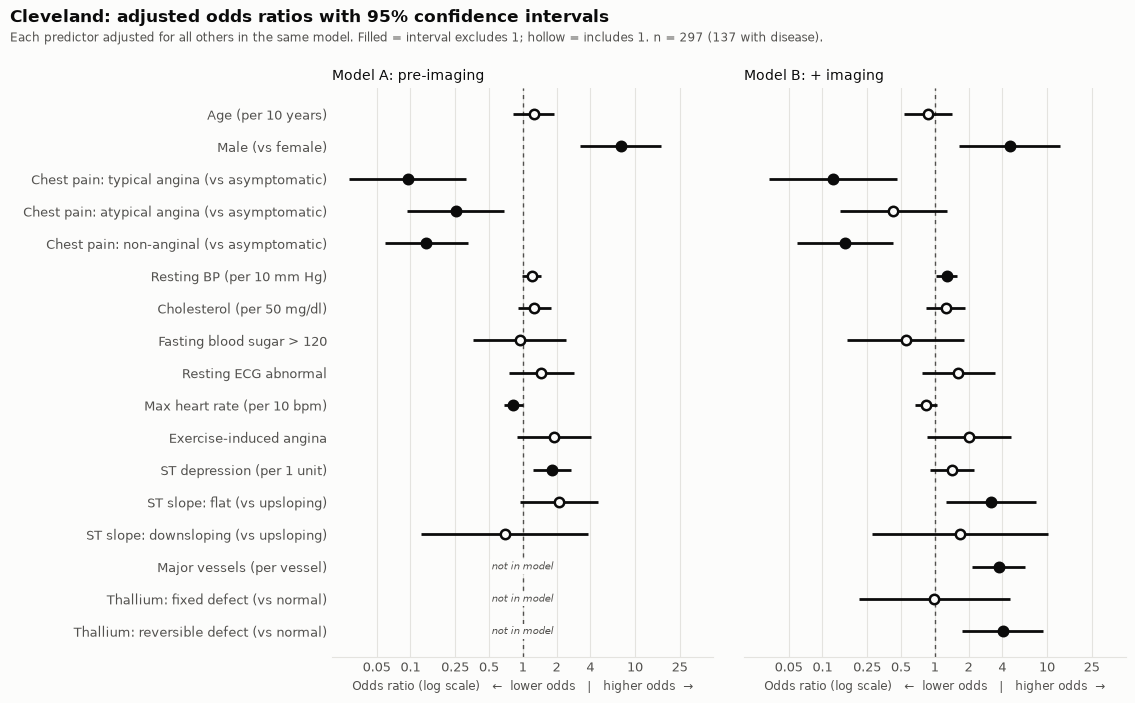

In [4]:
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9})

rows = list(LABELS.values())[::-1]
y = np.arange(len(rows))
fig, axes = plt.subplots(1, 2, figsize=(11.5, 7.2), sharey=True,
                         gridspec_kw={"wspace": 0.08})
for ax, name in zip(axes, FORMULAS):
    t = combined[name].reindex(rows)
    ax.axvline(1, color=INK_2, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    for yi, (label, r) in zip(y, t.iterrows()):
        if pd.isna(r["OR"]):
            ax.text(1, yi, "not in model", ha="center", va="center", fontsize=7.5,
                    color=INK_2, style="italic", zorder=3,
                    bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
            continue
        clear = r["CI low"] > 1 or r["CI high"] < 1
        ax.hlines(yi, r["CI low"], r["CI high"], color=INK, linewidth=2, zorder=2)
        ax.scatter(r["OR"], yi, s=46, zorder=3, linewidths=1.8, edgecolors=INK,
                   facecolors=INK if clear else SURFACE)
    ax.set_xscale("log")
    ax.set_xlim(0.02, 50)
    ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 4, 10, 25],
                  ["0.05", "0.1", "0.25", "0.5", "1", "2", "4", "10", "25"])
    ax.minorticks_off()
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.set_title(f"Model {name}", loc="left", fontsize=10, color=INK)
    ax.set_xlabel("Odds ratio (log scale)   ←  lower odds   |   higher odds  →",
                  color=INK_2, fontsize=8.5)
axes[0].set_yticks(y, rows)
fig.suptitle("Cleveland: adjusted odds ratios with 95% confidence intervals", x=0.01,
             ha="left", fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.935, "Each predictor adjusted for all others in the same model. "
         "Filled = interval excludes 1; hollow = includes 1. n = 297 (137 with disease).",
         fontsize=8.5, color=INK_2)
fig.subplots_adjust(left=0.29, right=0.98, top=0.87, bottom=0.08)
fig.savefig(ROOT / "reports" / "figures" / "cleveland_odds_ratios.png", dpi=200)
plt.show()

**Why a log scale?** Odds ratios are multiplicative: 0.5 (half the odds)
and 2 (double the odds) are equally large effects in opposite directions. On a
log scale they sit the same distance either side of 1.

## 3. Does adding the imaging help?

**Likelihood-ratio test.** Model B contains everything in Model A plus three
imaging coefficients. The test asks whether B fits the data better than A by
more than three extra coefficients would by chance.

In [5]:
fa, fb = fits["A: pre-imaging"], fits["B: + imaging"]
lr = 2 * (fb.llf - fa.llf)
df_diff = int(fb.df_model - fa.df_model)
print(f"Likelihood-ratio statistic = {lr:.1f} on {df_diff} degrees of freedom, "
      f"p = {stats.chi2.sf(lr, df_diff):.2g}")

Likelihood-ratio statistic = 43.6 on 3 degrees of freedom, p = 1.9e-09


## 4. How well do the models separate the groups?

**AUC (area under the ROC curve)** is the standard measure of how well a
model's predicted risk separates patients with and without disease. It is the
same idea as notebook 04's probability of superiority: pick one patient with
disease and one without; AUC is the chance the model gives the patient with
disease the higher risk. 0.5 is a coin toss, 1.0 perfect.

**Why cross-validation?** A model scored on the same patients it was fitted
to looks better than it really is, because it has partly memorised their
quirks. So: split the patients into 10 parts; fit on 9, predict the 10th;
rotate until every patient has a prediction from a model that never saw them.
The split is random, so the whole thing is repeated 20 times and the results
summarised.

In [6]:
def auc(y, score):
    # AUC = probability of superiority of the scores (ties count half)
    pos, neg = score[y == 1], score[y == 0]
    return stats.mannwhitneyu(pos, neg).statistic / (len(pos) * len(neg))

def stratified_folds(y, k, rng):
    # each fold gets the same share of disease cases as the whole sample
    folds = np.empty(len(y), dtype=int)
    for cls in (0, 1):
        idx = rng.permutation(np.flatnonzero(y == cls))
        folds[idx] = np.arange(len(idx)) % k
    return folds

y_all = m["disease"].to_numpy()
rng = np.random.default_rng(2026)
cv = {name: [] for name in FORMULAS}
for rep in range(20):
    folds = stratified_folds(y_all, 10, rng)
    for name, f in FORMULAS.items():
        pred = np.empty(len(m))
        for k in range(10):
            train, test = folds != k, folds == k
            fit = smf.logit(f, m[train]).fit(disp=False)
            pred[test] = fit.predict(m[test])
        cv[name].append(auc(y_all, pred))

perf = pd.DataFrame({
    "AUC on own data (optimistic)": [auc(y_all, fits[n].predict(m)) for n in FORMULAS],
    "AUC cross-validated (mean)": [np.mean(cv[n]) for n in FORMULAS],
    "range over 20 repeats": [f"{min(cv[n]):.3f}–{max(cv[n]):.3f}" for n in FORMULAS],
}, index=list(FORMULAS)).round(3)
perf

,AUC on own data (optimistic),AUC cross-validated (mean),range over 20 repeats
A: pre-imaging,0.901,0.869,0.864–0.877
B: + imaging,0.935,0.903,0.896–0.912


## 5. Why did age and sex change?

Two checks that explain the biggest shifts between the one-at-a-time results
and the adjusted ones.

In [7]:
num = cle[["age", "max_heart_rate", "major_vessels", "cholesterol"]].astype(float)
print("Correlation of age with max heart rate:", round(num["age"].corr(num["max_heart_rate"]), 2))
print("Correlation of age with vessel count:  ", round(num["age"].corr(num["major_vessels"]), 2))

t = pd.crosstab(cle["sex"], cle["disease"])
crude_or = (t.loc["male", True] / t.loc["male", False]) / (t.loc["female", True] / t.loc["female", False])
print(f"\nCrude odds ratio, men vs women: {crude_or:.1f}")
cle.groupby("sex", observed=True)[["age", "cholesterol"]].median().rename_axis("median by sex")

Correlation of age with max heart rate: -0.39
Correlation of age with vessel count:   0.36

Crude odds ratio, men vs women: 3.6


,age,cholesterol
median by sex,,
female,57.0,255.0
male,55.0,236.0


## 6. What the models say

### Adjusting changes the picture, in both directions

| Predictor | One at a time (notebook 04) | Adjusted, Model A | What changed |
|---|---|---|---|
| **Age** | clear (PS 0.64) | OR 1.25 per 10 years (0.82–1.91) | **No longer clear.** Older patients here also have lower max heart rates (correlation −0.39) and more diseased vessels (0.36). Once those are in the model, age adds little of its own |
| **Sex** | V 0.28; crude OR for men 3.6 | OR 7.5 (3.3–17.2) | **Stronger.** Women in this sample are slightly older (median 57 vs 55) and have higher cholesterol (255 vs 236), which on their own predict *more* disease. Compared with men who have the same measurements, women's disease rate is even lower than the raw gap suggests. The interval is wide, so the exact size is uncertain |
| **Chest pain type** | V 0.52 | typical angina OR 0.09, non-anginal 0.14 vs asymptomatic | **Holds.** Patients with no chest pain still have much higher odds, even among patients alike on everything else |
| **Exercise-test group** (angina, ST depression, ST slope, max heart rate) | all four clear | only ST depression (1.82 per unit) and max heart rate (0.82 per 10 bpm, just clear) | **Overlap confirmed.** The four measure much the same thing, so each loses strength when the others are present. Exercise angina and flat ST slope point the same way but their intervals include 1 |
| Cholesterol, fasting blood sugar, resting ECG | small or none | intervals include 1 | Still nothing clear |

### What the imaging adds

- **Model B fits much better than Model A** (likelihood-ratio test, p ≈ 2 × 10⁻⁹).
- **Each additional diseased vessel multiplies the odds by about 3.7**
  (2.1–6.4), and a reversible thallium defect by about 4.0 (1.8–9.3).
- **Cross-validated AUC rises from 0.87 to 0.90.** That's a real but modest
  gain on top of routine measurements that already separate the groups well.
  Recall that the imaging is close to the diagnostic procedure itself
  (notebook 03), so some of its strength is built in.
- With the imaging included, ST depression and max heart rate lose their clear
  intervals. The imaging captures much of the same information. Flat ST
  slope and resting blood pressure become clear, but only just (lower limits
  1.25 and 1.02).

### Two lessons about honesty in modelling

1. **A model scored on its own data flatters itself.** AUC is 0.90 / 0.94 on
   the fitting data and 0.87 / 0.90 when every patient is scored by a model
   that never saw them. The ~0.03 gap is over-fitting. The cross-validated
   numbers are the ones to quote.
2. **Don't read borderline intervals as discoveries.** Model B estimates 17
   coefficients and none of these intervals are corrected for multiple
   comparisons. At the 95% level, about one in twenty intervals would exclude 1 by
   chance alone. So a lower limit of 1.02 (blood pressure in Model B) is weak
   evidence, especially since the same variable wasn't clear in Model A or
   after correction in notebook 04.

### Limits

- **Associations, not causes.** "Holding others constant" only covers
  predictors in the model.
- **Referred patients only.** These odds ratios describe patients sent for
  angiography, not the general population.
- **Close to the sample-size limit** (8–10 disease cases per coefficient),
  hence the wide intervals for small groups like downsloping ST slope
  (n = 21) and fixed thallium defect (n = 18).
- **One site so far.** The next step checks whether the main patterns hold
  across all four sites.